In [1]:
# NOTE: Kaggle notebooks already include required packages listed by the user.
# Avoid notebook magics / pip installs in the final script to prevent runtime issues.



In [2]:
import os
import random
import numpy as np
import pandas as pd

import warnings

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)



device: cuda


In [3]:
# Keep I/O paths unchanged (use Kaggle input folder)
DATA_ROOT = "/kaggle/input/playground-series-s3e18"


class Datapreparation(object):
    def __init__(self, root_path):
        self.root_path = root_path
        # FIX: keep a single scaler fitted on training data, then reuse for val/test
        self.scaler = StandardScaler()

    def get_dataframe(self, filename):
        return pd.read_csv(os.path.join(self.root_path, filename))

    def summary(self, text, df):
        summary = pd.DataFrame(df.dtypes, columns=["dtypes"])
        summary["null"] = df.isnull().sum()
        summary["unique"] = df.nunique()
        summary["min"] = df.min(numeric_only=True)
        summary["median"] = df.median(numeric_only=True)
        summary["max"] = df.max(numeric_only=True)
        summary["mean"] = df.mean(numeric_only=True)
        summary["std"] = df.std(numeric_only=True)
        summary["duplicate"] = df.duplicated().sum()
        return summary

    def random_split_data(self, X, y):
        return train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)

    def fit_standardization(self, X_data):
        return self.scaler.fit_transform(X_data)

    def transform_standardization(self, X_data):
        return self.scaler.transform(X_data)


data = Datapreparation(DATA_ROOT)
train_df = data.get_dataframe("train.csv")
test_df = data.get_dataframe("test.csv")

print(train_df.shape, test_df.shape)



(13354, 38) (1484, 32)


In [4]:
# Targets
y1 = train_df["EC1"].copy()
y2 = train_df["EC2"].copy()

# Feature selection: preserve original "core logic" columns dropped
DROP_COLS = [
    "id",
    "EC1",
    "EC2",
    "EC3",
    "EC4",
    "EC5",
    "EC6",
    "BertzCT",
    "Chi1",
    "Chi1n",
    "Chi1v",
    "Chi2n",
    "Chi2v",
    "Chi3v",
    "Chi4n",
]

X = train_df.drop(columns=DROP_COLS, errors="ignore").copy()
test_features = test_df.drop(
    columns=["id"]
    + [
        c
        for c in DROP_COLS
        if c not in ["id", "EC1", "EC2", "EC3", "EC4", "EC5", "EC6"]
    ],
    errors="ignore",
).copy()

# Align columns just in case
test_features = test_features.reindex(columns=X.columns)

print("X:", X.shape, "test_features:", test_features.shape)



X: (13354, 23) test_features: (1484, 23)


In [5]:
# Split for EC1 (use same feature split indices; keep core logic of separate training per target)
X_train, X_val, y1_train, y1_val = data.random_split_data(X, y1)
_, _, y2_train, y2_val = data.random_split_data(X, y2)

# FIX: Fit scaler on X_train once and apply to val/test (previous code refit separately, leaking/noise)
std_X_train = data.fit_standardization(X_train.values)
std_X_val = data.transform_standardization(X_val.values)
std_X_test = data.transform_standardization(test_features.values)

print(
    "std_X_train:",
    std_X_train.shape,
    "std_X_val:",
    std_X_val.shape,
    "std_X_test:",
    std_X_test.shape,
)




std_X_train: (10683, 23) std_X_val: (2671, 23) std_X_test: (1484, 23)


In [6]:
class Tensoroperations:
    def convert_to_tensor(self, X, y):
        X_tensor = torch.from_numpy(X).float()
        y_tensor = torch.from_numpy(np.asarray(y)).float()
        return X_tensor, y_tensor

    def convert_to_test_tensor(self, X):
        return torch.from_numpy(X).float()


tenops = Tensoroperations()

X_tensor_train, y1_tensor_train = tenops.convert_to_tensor(std_X_train, y1_train.values)
X_tensor_val, y1_tensor_val = tenops.convert_to_tensor(std_X_val, y1_val.values)

_, y2_tensor_train = tenops.convert_to_tensor(std_X_train, y2_train.values)
_, y2_tensor_val = tenops.convert_to_tensor(std_X_val, y2_val.values)

X_tensor_test = tenops.convert_to_test_tensor(std_X_test)




In [7]:
# FIX: CustomDataset was broken (used X_train global for is_train=False and always returned y)
class CustomDataset(Dataset):
    def __init__(self, X_data, y_data):
        super().__init__()
        self.X_data = X_data
        self.y_data = y_data

    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]

    def __len__(self):
        return len(self.X_data)


class CustomDataTest(Dataset):
    def __init__(self, X_data):
        self.X_data = X_data

    def __getitem__(self, index):
        return self.X_data[index]

    def __len__(self):
        return len(self.X_data)


train1_dataset = CustomDataset(X_tensor_train, y1_tensor_train)
val1_dataset = CustomDataset(X_tensor_val, y1_tensor_val)

train2_dataset = CustomDataset(X_tensor_train, y2_tensor_train)
val2_dataset = CustomDataset(X_tensor_val, y2_tensor_val)

train_dataloader = DataLoader(train1_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val1_dataset, batch_size=64, shuffle=False)

train_dataloader2 = DataLoader(train2_dataset, batch_size=64, shuffle=True)
val_dataloader2 = DataLoader(val2_dataset, batch_size=64, shuffle=False)

test_dataset = CustomDataTest(X_tensor_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)



In [8]:
# Keep torchmetrics imports out (not needed for producing submission, and avoids extra API breakages).
# Preserve training semantics: BCE on sigmoid output.


class EnzymeClassificationBase(nn.Module):
    def training_step(self, batch):
        features, labels = batch
        out = self(features)
        loss = F.binary_cross_entropy(out, labels.unsqueeze(1))
        return loss

    def validation_step(self, batch):
        features, labels = batch
        out = self(features)
        loss = F.binary_cross_entropy(out, labels.unsqueeze(1))
        # lightweight proxy metric (not Kaggle AUC; just to monitor)
        acc = ((out.detach().squeeze(1) > 0.5).float() == labels).float().mean()
        return {"Validation_loss": loss.detach(), "Validation_acc": acc.detach()}

    def validation_epoch_end(self, outputs):
        batch_losses = [x["Validation_loss"] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x["Validation_acc"] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {
            "Validation_loss": epoch_loss.item(),
            "Validation_acc": epoch_acc.item(),
        }

    def epoch_end(self, epoch, result):
        if epoch % 10 == 0:
            print(
                f"Epoch [{epoch}], Train_loss: {result['Train_loss']:.4f}, "
                f"Validation_loss: {result['Validation_loss']:.4f}, Validation_acc: {result['Validation_acc']:.4f}"
            )


n_input_dim = X_tensor_train.shape[1]
n_output = 1


class MultiClassificationNN(EnzymeClassificationBase):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_input_dim, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 8),
            nn.LeakyReLU(),
            nn.Linear(8, n_output),
            nn.Sigmoid(),
        )

    def forward(self, xb):
        return self.network(xb)


model_EC1 = MultiClassificationNN().to(device)
model_EC2 = MultiClassificationNN().to(device)

print(model_EC1)




MultiClassificationNN(
  (network): Sequential(
    (0): Linear(in_features=23, out_features=32, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=8, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


In [9]:
class Trainer:
    @torch.no_grad()
    def _evaluate(self, model, val_loader):
        model.eval()
        outputs = []
        for batch in val_loader:
            features, labels = batch
            features = features.to(device)
            labels = labels.to(device)
            outputs.append(model.validation_step((features, labels)))
        return model.validation_epoch_end(outputs)

    def fit(self, epochs, lr, model, train_loader, val_loader, opt_func):
        history = []
        optimizer = opt_func(model.parameters(), lr=lr, weight_decay=2e-5)

        for epoch in tqdm(range(epochs)):
            model.train()
            train_losses = []
            for features, labels in train_loader:
                features = features.to(device)
                labels = labels.to(device)

                loss = model.training_step((features, labels))
                train_losses.append(loss.detach().cpu())

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            result = self._evaluate(model, val_loader)
            result["Train_loss"] = torch.stack(train_losses).mean().item()
            model.epoch_end(epoch, result)
            history.append(result)

        return history


num_epochs = 100
lr = 1e-4
opt_func = optim.Adam

trainer = Trainer()



In [10]:
history_EC1 = trainer.fit(
    num_epochs, lr, model_EC1, train_dataloader, val_dataloader, opt_func
)



  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [0], Train_loss: 0.7208, Validation_loss: 0.7121, Validation_acc: 0.3370
Epoch [10], Train_loss: 0.5849, Validation_loss: 0.5847, Validation_acc: 0.6902
Epoch [20], Train_loss: 0.5810, Validation_loss: 0.5827, Validation_acc: 0.6937
Epoch [30], Train_loss: 0.5790, Validation_loss: 0.5822, Validation_acc: 0.6907
Epoch [40], Train_loss: 0.5775, Validation_loss: 0.5821, Validation_acc: 0.6937
Epoch [50], Train_loss: 0.5764, Validation_loss: 0.5819, Validation_acc: 0.6922
Epoch [60], Train_loss: 0.5753, Validation_loss: 0.5819, Validation_acc: 0.6922
Epoch [70], Train_loss: 0.5744, Validation_loss: 0.5817, Validation_acc: 0.6929
Epoch [80], Train_loss: 0.5736, Validation_loss: 0.5816, Validation_acc: 0.6917
Epoch [90], Train_loss: 0.5727, Validation_loss: 0.5816, Validation_acc: 0.6939


In [11]:
history_EC2 = trainer.fit(
    num_epochs, lr, model_EC2, train_dataloader2, val_dataloader2, opt_func
)




  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [0], Train_loss: 0.7125, Validation_loss: 0.6881, Validation_acc: 0.5084
Epoch [10], Train_loss: 0.5059, Validation_loss: 0.5076, Validation_acc: 0.8007
Epoch [20], Train_loss: 0.5016, Validation_loss: 0.5038, Validation_acc: 0.8007
Epoch [30], Train_loss: 0.5004, Validation_loss: 0.5032, Validation_acc: 0.8007
Epoch [40], Train_loss: 0.4997, Validation_loss: 0.5031, Validation_acc: 0.8007
Epoch [50], Train_loss: 0.4991, Validation_loss: 0.5027, Validation_acc: 0.8007
Epoch [60], Train_loss: 0.4986, Validation_loss: 0.5028, Validation_acc: 0.8007
Epoch [70], Train_loss: 0.4982, Validation_loss: 0.5027, Validation_acc: 0.8007
Epoch [80], Train_loss: 0.4978, Validation_loss: 0.5028, Validation_acc: 0.8007
Epoch [90], Train_loss: 0.4974, Validation_loss: 0.5027, Validation_acc: 0.8007


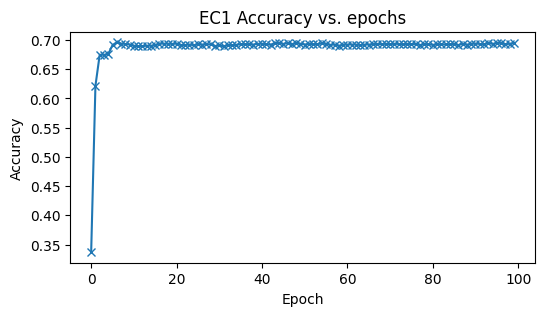

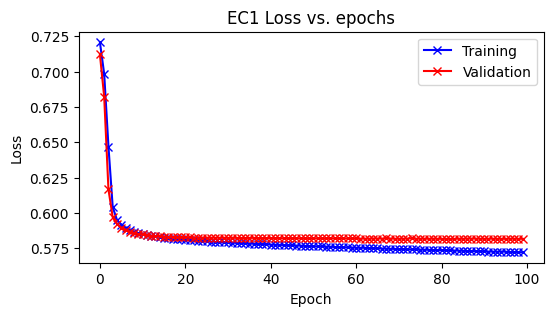

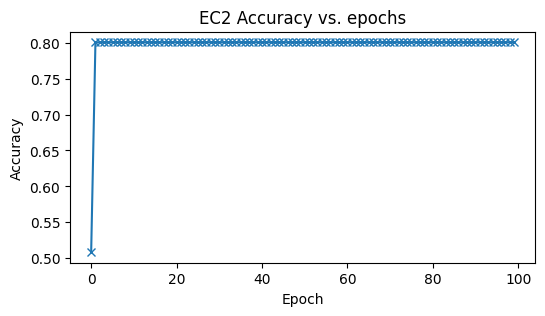

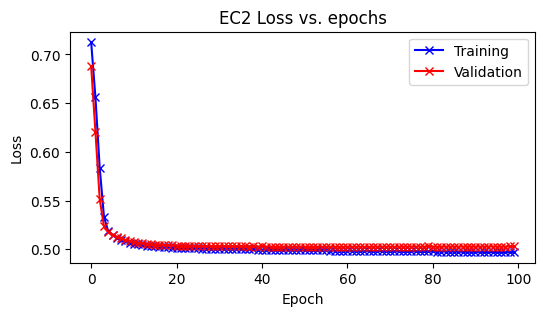

In [12]:
# Optional plots (won't affect submission); keep minimal
def plot_accuracies(history, title):
    accuracies = [x["Validation_acc"] for x in history]
    plt.figure(figsize=(6, 3))
    plt.plot(accuracies, "-x")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.show()


def plot_losses(history, title):
    train_losses = [x.get("Train_loss") for x in history]
    val_losses = [x["Validation_loss"] for x in history]
    plt.figure(figsize=(6, 3))
    plt.plot(train_losses, "-bx")
    plt.plot(val_losses, "-rx")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Training", "Validation"])
    plt.title(title)
    plt.show()


plot_accuracies(history_EC1, "EC1 Accuracy vs. epochs")
plot_losses(history_EC1, "EC1 Loss vs. epochs")
plot_accuracies(history_EC2, "EC2 Accuracy vs. epochs")
plot_losses(history_EC2, "EC2 Loss vs. epochs")




In [13]:
# FIX: model outputs are already probabilities due to final Sigmoid layer.
# Previous code applied torch.sigmoid again, harming calibration (score).
class Evaluate:
    def eval_test_data(self, model, test_data_dl):
        preds = []
        model.eval()
        with torch.no_grad():
            for X_batch_test in test_data_dl:
                X_batch_test = X_batch_test.to(device)
                y_pred = model(X_batch_test).squeeze(1)  # already in [0,1]
                preds.append(y_pred.detach().cpu().numpy())
        return np.concatenate(preds, axis=0)


eva = Evaluate()
ec1 = eva.eval_test_data(model_EC1, test_dataloader)
ec2 = eva.eval_test_data(model_EC2, test_dataloader)

print("pred shapes:", ec1.shape, ec2.shape)



pred shapes: (1484,) (1484,)


In [14]:
# Create submission
submission = pd.DataFrame(
    {
        "id": test_df["id"].values,
        "EC1": ec1.astype(float),
        "EC2": ec2.astype(float),
    }
)

# Safety checks for Kaggle format
assert submission.shape[0] == test_df.shape[0]
assert list(submission.columns) == ["id", "EC1", "EC2"]

submission.to_csv("submission.csv", index=False)
print("Wrote submission.csv:", submission.shape)
submission.head()

Wrote submission.csv: (1484, 3)


,id,EC1,EC2
0,1377,0.764864,0.742534
1,5485,0.687500,0.813088
2,8753,0.457278,0.827141
3,10746,0.720484,0.795560
4,7554,0.452505,0.837961
